In [1]:
# 2.5 D DC model= 2D conductivity dist + 3D point sources (current dist is 3D)

In [2]:
# refer to nb for explanation of math

In [3]:
import matplotlib
import numpy as np
import pygimli as pg

from pygimli.viewer.mpl import drawStreams

In [4]:
def uAnalytical(p, sourcePos, k, sigma=1):
    """Calculates the analytical solution for the 2.5D geoelectrical problem.

    Solves the 2.5D geoelectrical problem for one wave number k.
    It calculates the normalized (for injection current 1 A and sigma=1 S/m)
    potential at position p for a current injection at position sourcePos.
    Injection at the subsurface is recognized via mirror sources along the
    surface at depth=0.

    Parameters
    ----------
    p : pg.Pos
        Position for the sought potential
    sourcePos : pg.Pos
        Current injection position.
    k : float
        Wave number

    Returns
    -------
    u : float
        Solution u(p)
    """
    r1A = (p - sourcePos).abs()
    # |r-rs+|
    # Mirror on surface at depth=0
    r2A = (p - pg.Pos([1.0, -1.0])*sourcePos).abs()
    # |r-rs-|... the x coord. is multiplied by 1 (its the same) and z coord multipled by -1

    if r1A > 1e-12 and r2A > 1e-12:
        return  1 / (2.0 * np.pi) * 1/sigma * \
            (pg.math.besselK0(r1A * k) + pg.math.besselK0(r2A * k))
    else:
        return 0.

In [5]:
def mixedBC(boundary, userData): # for defining what happend to electric field at boundaries 
    r"""Mixed boundary conditions.

    Define the derivative of the analytical solution regarding the outer normal
    direction :math:`\vec{n}`. So we can define the values for mixed boundary
    condition :math:`\frac{\partial u}{\partial \vec{n}} = -au`
    for the boundaries on the subsurface.

    """
    ### ignore surface boundaries for wildcard boundary condition
    if boundary.norm()[1] == 1.0: # z coord is 1 
        return 0

    sourcePos = userData['sourcePos']
    k = userData['k']
    sigma = userData['s']
    r1 = boundary.center() - sourcePos

    # Mirror on surface at depth=0
    r2 = boundary.center() - pg.Pos(1.0, -1.0) * sourcePos
    r1A = r1.abs()
    r2A = r2.abs()

    n = boundary.norm()
    if r1A > 1e-12 and r2A > 1e-12:
        alpha = sigma * k * ((r1.dot(n)) / r1A * pg.math.besselK1(r1A * k) +
                            (r2.dot(n)) / r2A * pg.math.besselK1(r2A * k)) / \
            (pg.math.besselK0(r1A * k) + pg.math.besselK0(r2A * k))

        return alpha

        # Note, the above is the same like:
        beta = 1.0
        return [alpha, beta, 0.0]

    else:
        return 0.0

In [6]:
def rhsPointSource(mesh, source):
    r"""Define function for the current source term.

    :math:`\delta(x-pos), \int f(x) \delta(x-pos)=f(pos)=N(pos)`
    Right hand side entries will be shape functions(pos)
    """
    rhs = pg.Vector(mesh.nodeCount())

    cell = mesh.findCell(source) # source point 
    rhs.setVal # for each cell
    (cell.N # gives an array of numbers which show the dist between electrode and that node of cell
               (cell.shape().rst(source) # makes (r,s,t) coordinates
                     ), cell.ids())
    return rhs

In [7]:
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

mesh = pg.createGrid(x=np.linspace(-10.0, 10.0, 41),
                     y=np.linspace(-15.0, 0.0, 31))
mesh = mesh.createP2() # converting into quadratic (higher-order) finite element mesh

sourcePosA = [-5.25, -3.75] # left electrode 
sourcePosB = [+5.25, -3.75] # right electrode 
sigma = 1.0

In [8]:
def get_rhs(mesh_obj, source_coords): # converts coord into corresponding vector
    rhs_vec = pg.Vector(mesh_obj.nodeCount(), 0.0) # basically initializing b in A.u=b
    source_cell = mesh_obj.findCell(source_coords) # finds source cell
    if source_cell: # to ensure source cell is in the mesh
        rhs_vec.setVal(
            source_cell.N # cell shape 
            (source_cell.shape().rst(source_coords # converts cell coord into r,s,t format 
                   )), source_cell.ids())
    return rhs_vec

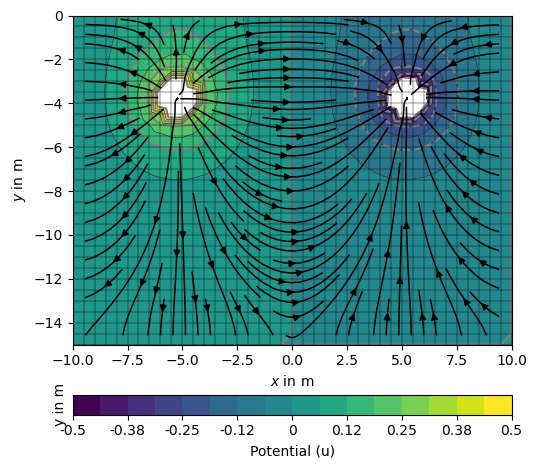

In [9]:
wavenumbers = [0.0035, 0.0118, 0.0395, 0.1323, 0.4431, 1.4841, 4.9708, 16.649]
weights = [0.0071, 0.0241, 0.0811, 0.2718, 0.9103, 3.0489, 10.224, 34.195 # corresponding weights for each k

uA_total = pg.Vector(mesh.nodeCount(), 0.0)
uB_total = pg.Vector(mesh.nodeCount(), 0.0)
# 2 empty arrays 

for k, w in zip(wavenumbers, weights): # looping through each k and its corrsponding weight 
    
    # current injection vectors
    rhsA = get_rhs(mesh, sourcePosA)
    rhsB = get_rhs(mesh, sourcePosB)
    
    # zero-potential float boundary condition definition
    uA = pg.solve(mesh, a=sigma, b=-sigma * k * k, rhs=rhsA, bc={'Dirichlet': {'1,2,3': 0.0}}, verbose=False)
    uA_total += uA * w
    
    uB = pg.solve(mesh, a=sigma, b=-sigma * k * k, rhs=rhsB, bc={'Dirichlet': {'1,2,3': 0.0}}, verbose=False)
    uB_total += uB * w

# superpostion (to get final dipole field)
u_dipole = uA_total - uB_total

ax, cbar = pg.show(mesh, data=u_dipole, cMap="viridis", cMin=-0.5, cMax=0.5,
                   orientation='horizontal', label='Potential $u$ (V)',
                   nCols=16, nLevs=9, showMesh=True)

v_grad = pg.solver.grad(mesh, u_dipole)
gx = -v_grad[:, 0]  # Horizontal vector component
gz = -v_grad[:, 1]  # Vertical depth vector component

x_vec = np.linspace(-10.0, 10.0, 100)
z_vec = np.linspace(-15.0, 0.0, 100)
X, Z = np.meshgrid(x_vec, z_vec)

# geometric midpoints of mesh elements 
cell_centers = [cell.center() for cell in mesh.cells()]
cc_x = [p[0] for p in cell_centers]
cc_z = [p[1] for p in cell_centers]

# adding
UX = griddata((cc_x, cc_z), gx, (X, Z), method='linear', fill_value=0)
UZ = griddata((cc_x, cc_z), gz, (X, Z), method='linear', fill_value=0)
ax.streamplot(X, Z, UX, UZ, color='black', linewidth=1.1, density=1.2)

plt.xlabel('Potential (u)')
plt.ylabel('y in m')
plt.show()

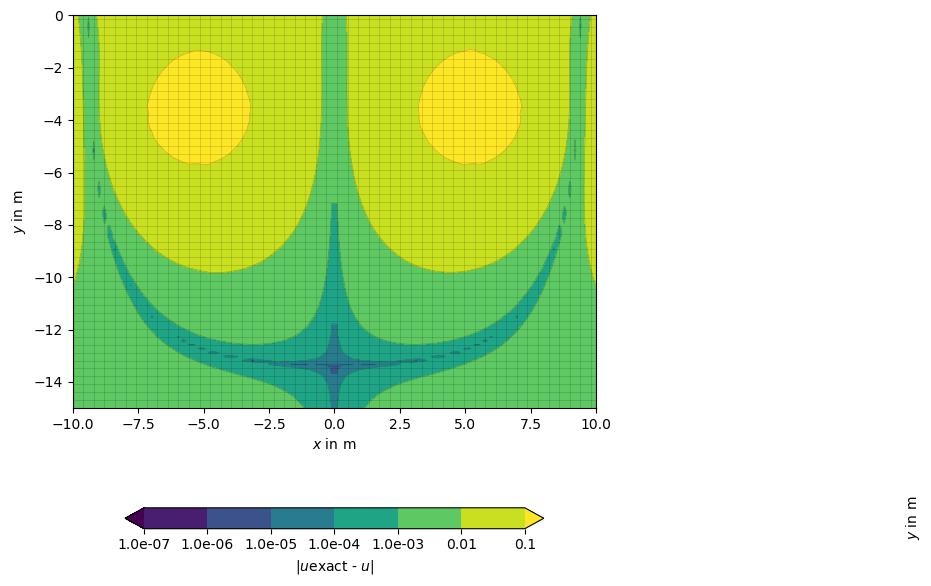

In [46]:
# making the exact graph (analytical sol)
fig1, ax1 = plt.subplots(figsize=(8, 7))

levels = [1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 0.01, 0.1]

contour = ax1.contourf(X, Z, error, levels=levels, norm=LogNorm(), cmap=plt.cm.viridis, extend='both')
# norm is for logarithmic color scale
# extends is for outliers 

# mesh
for x in x_vec[::2]: # 2 units
    ax1.axvline(x, color='black', alpha=0.15, linewidth=0.6)
for z in z_vec[::2]:
    ax1.axhline(z, color='black', alpha=0.15, linewidth=0.6)

ax1.contour(X, Z, error, levels=levels, norm=LogNorm(), colors='black', alpha=0.25, linewidths=0.5)

ax1.set_aspect('equal')
ax1.set_xlim(-10.0, 10.0)
ax1.set_ylim(-15.0, 0.0)
ax1.set_xlabel('$x$ in m')
ax1.set_ylabel('$y$ in m')

# scale
cbar1 = fig1.colorbar(contour, ax=ax1, orientation='horizontal', pad=0.15, shrink=0.8)
cbar1.set_label('|$u$exact - $u$|') 

# intervals
cbar1.set_ticks(levels)
cbar1.ax.set_xticklabels(['1.0e-07', '1.0e-06', '1.0e-05', '1.0e-04', '1.0e-03', '0.01', '0.1'])

cbar1.ax.set_ylabel('$y$ in m', rotation=90, labelpad=-560, y=0.5)

plt.tight_layout()
plt.show()